---
title: Quantifying Indifference Towards Palestinian Suffering Across UK News Sources
date: 2024-09-09
author: 
  - name: Johannes Van Cauwenberghe
    email: johannes.vc@hotmail.com
    affiliation: 
      - name: University of London
        department: MSc Data Science

format: 
    html:
        toc: true
        number-sections: false
        self-contained: true
    
license: "CC BY"
callout-icon: false

---

#### 1. Introduction

This project seeks to analyse media coverage of the Palestinian-Israeli conflict across various UK news outlets. Through a detailed investigation of language, sentiment, and reporting patterns, the goal is to quantify the extent of media bias or indifference towards Palestinian suffering. Specifically, the project focuses on whether UK media outlets exhibit consistent discrepancies in their reporting on this issue. 

The project builds on similar studies, such as Jackson (2023), who contrasts mentions of Palestinian and Israeli casualties in the New York Times with actual casualty figures. Expanding on this, we incorporate Natural Language Processing (NLP) techniques such as opinion mining to examine how different UK outlets present, emphasise, or downplay Palestinian and Israeli casualties, with a focus on the nuances of language that contribute to framing and perception.
   
#### 1.1 Research Questions and Objectives

- **Primary Objective**: To compare how different UK media outlets report on the Palestinian-Israeli conflict.
  
- **Key Questions**:
  - How do UK media outlets differ in language and sentiment when reporting on Palestinian versus Israeli casualties?
  - Can we detect "indifference" in media reporting, defined as a false equivalence that obscures the disproportionate suffering of one group?

Given that this project is primarily a data science investigation, we shall avoid complex issues of media ownership, political affiliations, or geopolitical implications. These issues, though important, are beyond the scope of this study. Instead, the focus is on the ethical imperative of recognising all human suffering as equally deserving of attention and empathy, which drives the need to examine media bias in this context.


#### 1.2 Methodology

The project utilises a combination of scraping, pre-processing, and advanced NLP techniques to analyse media coverage:

1. **Scraping UK News Media**:
   We will scrape BBC News articles on the Middle East and use APIs for other sources. Since some outlets, like The Guardian, restrict scraping, we will rely on open APIs like NewsAPI and EventRegistry to access article metadata and content. These tools allow us to efficiently collect a diverse set of articles while complying with usage restrictions.

2. **NLP Pipeline**:
   Using SpaCy, the pipeline will extract key linguistic features from articles, particularly verbs associated with violence (e.g., "kill", "murder"). The pipeline will also analyse the construction of sentences, identifying whether Palestinian or Israeli deaths are framed in active or passive voice (e.g., "Israeli forces killed..." vs. "Palestinians were killed by..."). This is critical in revealing potential biases in how violence is reported by different outlets.

3. **Sentiment Analysis**:
   Sentiment analysis will be performed using NLTK’s Sentiment Intensity Analyzer (SIA) to assess the polarity of sentences. By comparing sentiment patterns in reports of Palestinian and Israeli deaths, we aim to detect subtle differences in how emotions are conveyed, which may reflect underlying biases in the emotional framing of events.

4. **Entity Recognition**:
   SpaCy’s Named Entity Recognition (NER) will be used to classify mentions of Palestinians and Israelis, allowing us to cluster and compare their frequency and treatment across outlets. This will help quantify how often each group is mentioned and how they are framed in news coverage.

5. **Data Visualisation**:
   Tools like Seaborn and Matplotlib will be used to visualise sentiment distributions, entity mention frequencies, and trends over time. This will help illustrate the differences in reporting between outlets and highlight potential patterns of bias or indifference.

#### 1.3 Theoretical Framework

This study draws on two key approaches to Natural Language Processing, both of which are detailed in the NLTK Handbook, *Natural Language Processing with Python* (Bird et al., 2010). 

The first approach uses *part-of-speech (POS) tagging* to identify noun phrases, as described in Chapter 7, *Extracting Information from Text*. This method involves traversing syntactic trees by recursively processing noun phrases. This is useful for identifying key entities and their relationships in a structured manner, based on POS tags.

The second approach, and the one we predominantly use in our analysis, is *dependency grammar*. Detailed in Chapter 8, *Analysing Sentence Structure*, this approach focuses on the grammatical dependencies between words, identifying the *head* (usually the main verb) and its *dependents*. Dependency parsing allows us to explore how subjects, verbs, and objects are linked, providing a deeper understanding of sentence structure, which is crucial for identifying active and passive voice. 

While both approaches provide valuable insights, we opted for dependency grammar due to its ability to capture the relationships between entities and actions, which is crucial for analysing how violence is framed in news articles.

For sentiment analysis, we draw on the work of Liu et al. (2012) and Chen et al. (2009), who address key challenges in opinion mining and sentiment analysis, including the assessment of aspect and entity-level sentiment. However, recognising that sentiment scoring models are often biased, particularly against Arab and Muslim communities, we are mindful that the extent of anti-Palestinian bias in media reporting may be deeper than what our current technology can detect. And we shall remind the reader throughout the analysis of this systemic limitation.

#### Notes on Scraping and the Use of APIs

This project follows ethical guidelines for data collection, respecting each platform's policies. For the BBC, open-source scraping is permitted under their guidelines, while The Guardian restricts any form of scraping, even for analytical purposes. NewsAPI provides access under a fair use policy, which we strictly adhere to, ensuring no commercial use or redistribution. Other API services, such as Newsdata.io, WorldNewsAPI, and Webz.io, offer similar access to news data under limited free access plans. The restriction is often in time. None go further back than 31 days. While we explored a range of services, we converged on NewsAPI. 

---

## 2. Data Extraction and Preprocessing

This section of the project is divided into two primary stages: 

1. **Stage 1: BBC News Scraper** – We build a custom web scraper to extract articles from BBC News.
2. **Stage 2: NewsAPI Extraction** – We supplement the BBC data with additional articles pulled from an API, specifically focusing on a broader set of sources available through EventRegistry (formerly NewsAPI).

Each of these stages involves data extraction, cleaning, and pre-processing steps designed to ensure the dataset is suitable for analysis. Below, we will walk through both approaches in detail.

### 2.1 BBC News Scraper

The BBC scraper is specifically designed to target articles from the BBC's Middle East section, focusing on keywords related to the Palestinian-Israeli conflict. This approach circumvents the limitations of news APIs (such as the lack of full text in some cases) and allows us to gather a larger and more specific dataset.

**Scraping Functionality**: 
We start by defining several key functions:

- `get_soup(url)`: This function takes a URL and returns a BeautifulSoup object. The BeautifulSoup library allows us to parse HTML pages, enabling the extraction of article data from each page.
  
- `get_middle_east_article_links(test)`: This function crawls the BBC's Middle East section and collects links to articles that contain specific keywords (e.g., "Palestine", "Israel", "Gaza"). The function uses regular expressions to identify and filter these keywords from headlines.

- `get_article_text(article_link)`: Once we have a list of article links, this function extracts the article’s title, body, author, and publication date from the HTML structure of each BBC article.

**Pipeline**: 
The `scrape_BBC()` function orchestrates the entire process. It first collects all article links, then iterates over each link to extract the text content, which is stored in a list of dictionaries.

`scrape_BBC()` takes about 15 minutes to complete due to the size of the dataset and the number of articles. It results in a list of dictionaries, where each dictionary contains all relevant fields from each article (title, body, date, etc.).

#### 2.1.1 Preprocessing the Scraped Data

The `preprocess_bbc()` function takes the list of articles and reformats the dataset into a cleaner, more analysis-ready DataFrame. The main steps include:

1. **Date Parsing**: Converting publication dates into a consistent datetime format.
2. **Length Calculation**: Adding a column that calculates the length of each article (in characters).
3. **Source Identification**: Adding a column indicating that these articles are from "BBC News".
4. **Sentiment Placeholder**: Adding an empty sentiment column, which will later be used to store sentiment analysis results.

preprocess_bbc(bbc_df) emits a processed DataFrame that is saved to a file for later analysis.

In [1]:
from eventregistry import EventRegistry, QueryArticlesIter

import unittest
from unittest.mock import patch, Mock
import json, os, requests, re
from collections import defaultdict
from bs4 import BeautifulSoup 
from time import sleep
from tqdm import tqdm; tqdm.pandas()
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import colorcet as cc
import seaborn as sns; sns.set_theme('notebook', 
                                     style='dark', 
                                     rc={'figure.figsize':(10,6)})  # default is (6.4, 4.8)
                                                                    # 10/6 is golden ratio

import spacy
from nltk.sentiment import SentimentIntensityAnalyzer

pd.options.display.max_colwidth = 100
plt.rcParams['text.usetex'] = True

# Older verions of Jupyter require this line
# %matplotlib_inline

In [645]:
def get_soup(url: str) -> BeautifulSoup:
    """
    Takes any link and returns its soup.

    :params url: A well-formed hyperlink.
    :returns: A BeautifulSoup object containing the elements of the HTML tree in a navigable way,
              or None if the request fails.
    """
    headers = {"User-Agent": 
               "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"}
    try:
        html = requests.get(url, headers=headers)
        html.raise_for_status()
        return BeautifulSoup(html.text, 'html.parser')
    
    except Exception as e:
        print('Error with request:', e)
    
    return None

def get_middle_east_article_links(test) -> list:
    """
    Browses through the Middle East section and collects urls for each article mentioning one of a series of keywords.

    :returns: A list of hyperlinks to article pages.  
    """
    links = []

    pattern = re.compile(r"Palest|West Bank|Gaza|Israel|Netanyahu|Hamas")

    BASE_URL = "https://www.bbc.co.uk/news/world/middle_east"
    REGEX = re.compile(r'/news/articles/.*')

    # BBC's `middle_east` section has 41 pages as shown in the browser UI 
    # To construct the url, create a list from 1 to 41
    pages = [f'?page={i}' for i in range(1,42)]     
    
    # Iterate over pages to construct urls
    for page_url in tqdm(pages):
        soup = get_soup(BASE_URL + page_url)

        # Iterate over a-tags with a href element corresponding to our pattern
        for l in soup.find_all('a', href=REGEX):
            if "href" in l.attrs:
                link = l.get('href')

                headline = l.get_text(separator=' ')
                if re.search(pattern, headline):
                    
                    links.append('https://www.bbc.co.uk' + link)
        
        if test: break
        sleep(0.2)   # To even out spread server load

    return list(set(links))


def get_topic_article_links(test) -> list:
    """
    Browses through the ``Israel-Gaza war`` *topic* section and 
    collects urls starting with ``world-middle-east`` or ``uk-politics``.

    :returns: A list of hyperlinks to any news page.  
    """
    links = []

    BASE_URL = "https://www.bbc.co.uk/news/topics/cgv64vq5z82t"
    REGEX = re.compile(r'/news/world-middle-east.*|/news/uk-politics.*')
    
    # `Gaza` section has 42 pages
    pages = [f'?page={i}' for i in range(1,43)]     

    for page_url in tqdm(pages): 
        soup = get_soup(BASE_URL + page_url)

        # Iterate over a-tags with a href element corresponding to our pattern, 
        # which is adjusted here to broaden our reach
        for l in soup.find_all('a', href=REGEX):
            if "href" in l.attrs:
                link = l.get('href')
                
                links.append('https://www.bbc.co.uk' + link)
        
        if test: break
        sleep(0.2)  # To even out spread server load

    return list(set(links))

def get_article_text(article_link: str) -> dict:
    """
    Takes a link and captures its text.

    :param article_link: The fully-formed hyperlink to the page. 
    :returns: A dictionary with title, author, date, and body.
    """

    soup = get_soup(article_link)

    timestamp = None
    try:
        if soup.find('h1'):
            # If the h1 tag contains no text, try its child
            if soup.h1.get_text(separator=' '):
                title = soup.h1.get_text(separator=' ')
            else:
                title = soup.h1.findChild().get_text(separator=' ')
        
        text = {'title': title, 
                'url': article_link,
                'body': ''}

        # Try getting the datetime attribute (a timestamp)
        timestamp = soup.time.attrs.get('datetime')
        text['date'] = timestamp

        for div in soup.find_all('div'):
            # Important elements have attribute tags
            if 'data-component' in div.attrs:

                if 'byline-block' == div.attrs.get('data-component'):
                    text['author'] = div.get_text(separator=' ')                

                if 'text-block' == div.attrs.get('data-component'):
                    text['body'] += div.get_text(separator='\n')

                # Older articles have dates
                if 'metadata-block' == div.attrs.get('data-component'):
                    date = div.get_text(separator=' ')

        # Fall back on date if timestamp is not present            
        if timestamp is None and date is not None:
            text['date'] = date

        return text
    
    except Exception as e:
        # Log failing link and continue
        print(article_link, "failed. Reason:", e.args)

In [1331]:
# NOTE: This takes ~15 minutes to complete
def scrape_BBC(test=False) -> list[dict]:
    """
    Scrape all pages as defined above.

    :params test: Test scraper by providing a ``bool`` value. This will then scrape one page each of article links, and one page of articles.
    :returns: A list of dictionaries, containing all relevant fields.
    """
    # Get middle east article links
    article_links = get_middle_east_article_links(test)         # 313 links

    # Get Gaza topic article links
    more_links = get_topic_article_links(test)                  # 631 links

    # Remove duplicates
    unique_links = list(set(article_links + more_links))

    # Iterate over list using tqdm for a progress bar
    list_of_articles = []
    for article_link in tqdm(unique_links):
        list_of_articles.append(get_article_text(article_link))
        
        # Test
        if test: break
        
    return list_of_articles

list_of_articles = scrape_BBC()

100%|██████████| 631/631 [09:10<00:00,  1.15it/s] 


In [652]:
# A simple unit test for get_soup
# For demonstration purposes

# Inherit from ``TestCase``
class TestSoup(unittest.TestCase):

    # Patching the request itself, following best practice examples
    @patch('requests.get')
    def test_get_soup_valid_url(self, mock_get):
        # Mock the response from requests.get
        mock_response = Mock()
        mock_response.status_code = 200
        mock_response.text = '<a>a tag</a>'
        mock_get.return_value = mock_response
        
        # Get the soup
        soup = get_soup('http://www.bbc.co.uk/')
        
        # Check for h1
        self.assertEqual(soup.a.text, 'a tag')

unittest.main(argv=[''], exit=False, verbosity=0)

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [660]:
# A more succinct test
# Note that we will only perform assertions in what follows
test_scrape_BBC = scrape_BBC(test=True)
assert len(test_scrape_BBC) == 1, f"The length is not one, but {len(test_scrape_BBC)}"
assert type(test_scrape_BBC) == list, f"The type is not list, but {type(test_scrape_BBC)}"
assert 'body' in test_scrape_BBC[0], f"'body' is not in scrape_BBC"

In [1351]:
# Load list of dictionaries into a DataFrame
bbc_df = pd.DataFrame(list_of_articles)

In [1354]:
def preprocess_bbc(bbc_df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes a DataFrame, reformats the date as a datetime, add a length column, a source column, a language column and sentiment column.    

    :params bbc_df: A DataFrame with the list of dictionaries created above.
    :returns: A fully preprocessed DataFrame ready for concatenation.

    .. Note:: 
        The sentiment is set to ``NaN`` to prepare for a join. 
    """
    df = bbc_df.copy()

    # Extract a date in the form ``Published on 08 Sept 2024``
    df['dateTimePub'] = df.date.str.extract(r"(\d{1,2} \w* \d{4})$")
    df['dateTimePub'] = pd.to_datetime(df['date'], utc=True)
    df = df.dropna(subset='dateTimePub').set_index('dateTimePub').sort_index()['2023-09-01':]
    df = df.reset_index()

    # Add columns to align with API data structure
    df['source'] = "BBC News"
    df['lang'] = "eng"
    df['sentiment'] = np.nan

    df = df.drop(['date', 'author'], axis=1)
    return df

bbc_articles = preprocess_bbc(bbc_df)


### 2.2 NewsAPI Extraction

In this stage, we use the EventRegistry API to retrieve news articles from other media outlets. While the BBC scraper allows us to capture a significant amount of data from one source, the API broadens the scope by including articles from various outlets, adding diversity to our dataset.

#### 2.2.1 Data Overview and Preprocessing

**API Request**: The function `get_news()` handles the API requests, using the EventRegistry client to search for articles related to the Gaza Strip, published in the United Kingdom, and in English.

**Preprocessing**: Just like the BBC dataset, the articles retrieved from the API are preprocessed to ensure consistency. Unnecessary columns are removed, and date and source columns are formatted. A review of the dataset using `df.info()` indicates that most data types are correctly identified, but a few issues need resolution:



1. The `source` column is a nested dictionaries of the form:

    ```python
    {
        'uri': 'thecanary.co', 
        'dataType': 'news', 
        'title': 'The Canary'
    }	
    ```
    
2. The `authors` column has 429 empty values and is of the shape:
   
    ```python
    [
        {
            'uri': 'archie_bland@theguardian.com', 
            'name': 'Archie Bland', 
            'type': 'author', 
            'isAgency': False
        }
    ]   
    ```

    Some entries include multiple authors, but this complexity is deemed irrelevant for this analysis.

3. Various columns contain little information:
- `sim` appears to be the similiarity to the category definition. 
- `wgt` (weight) and `relevance` show the value of 100 for each row.
- `dataType` contains 'news' in every row.

We will now implement this functionality in Python and provide docstrings and comments to further explain the code. 

In [2]:
# Uncomment below for testing
# This loads a shuffled sample of the 6218 articles extracted in ``get_news`` and ``get_more_news``

# newsapi_df = pd.read_parquet('data/1000articles') 

In [1187]:
def get_news(date_start: datetime = "2024-08-08", 
             date_end: datetime = datetime.now().strftime('%Y-%m-%d')) -> list[dict]:
    """
    Using the Python SDK as per the `docs <https://github.com/EventRegistry/event-registry-python/wiki>`_.    
    
    :params date_start: The start date (furthest away in time).
    :params date_end: The recent date. Defaults to now.
    :returns: A list of articles in a dict.
    :Note: 
        The apiKey has about 1500 requests left and will then expire. 
    """
    er = EventRegistry(apiKey = "4ba71b97-06ff-4c4f-b7ee-2dc76371b2f4")
    
    query = QueryArticlesIter(
        conceptUri=er.getConceptUri("Gaza Strip"),
        sourceLocationUri=er.getLocationUri("United Kingdom"),
        lang="eng",
        dateStart=date_start,
        dateEnd=date_end 
    )
    try:
        return list(query.execQuery(er))
        
    except Exception as e:
        print(e)

def get_more_news(articles: list[dict]) -> pd.DataFrame:
    """
    Take the DataFrame, get at the oldest date, and request the rest from the API.

    :params df: The DataFrame with a ``dateTimePub`` column. 
    :returns: A joined DataFrame.
    """
    df = pd.DataFrame(articles)

    date_end = pd.to_datetime(df.dateTimePub).min().strftime('%Y-%m-%d')

    more_articles = get_news(date_end = date_end)

    df2 = pd.DataFrame(more_articles)

    return pd.concat([df, df2], axis=0)

In [1214]:
# Get first 500
newsapi = get_news()

# Get rest of the month (~5718)
newsapi_df = get_more_news(newsapi)

In [ ]:
# Check
assert newsapi_df.dataType.unique() == ["news"], f"DataType contains not just news, but: {newsapi_df.dataType.unique()}"

In [19]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes a DataFrame, preprocesses it and returns a DataFrame. 

    :params df: The unprocessed DataFrame.
    :returns: A DataFrame with preprocessed results. 
    """
    # Create a local copy
    pre_df = df.copy()

    # Unnest ``source`` from the nested dict
    pre_df['source'] = pre_df.source.apply(lambda row: row['title'])
    pre_df.source = pre_df.source.str.strip()

    # Set type
    pre_df.dateTimePub = pd.to_datetime(pre_df.dateTimePub)    

    # Return selected columns
    return pre_df.drop(['uri', 'isDuplicate', 'date', 'time', 'dateTime', 'dataType', 'sim', 'image', 
                    'authors', 'eventUri', 'relevance', 'wgt'], axis=1)

preprocessed_df = preprocess(newsapi_df)

#### 2.2.2 Handling Duplicates

The dataset contains 249 duplicate entries in the `url` column and an additional 3,035 duplicates in the `body` column. While we exclude these duplicates from the analysis to ensure we're only evaluating unique content, we retain a *mapping of duplicates* to attribute the analysis results to all sources that published the same material. This allows us to account for potential patterns of indifference across various media outlets, including those that syndicate content.

Below, we will show that many duplicates come from *local newspapers*, often republishing syndicated content. Although some duplicates remain in the `title` column, our analysis focuses on the `body` content, and we proceed with the deduplicated dataset based on this. This approach ensures the analysis remains focused on unique textual content, while the retained mapping allows us to attribute each piece of content to all its sources.

In [7]:
# Sources with most duplicated ``body``
preprocessed_df[preprocessed_df.duplicated('body')].source.value_counts().head(10)

source
Oxford Mail                             97
Belfast Telegraph                       96
Shropshire Star                         94
Basingstoke Gazette                     93
Bridport and Lyme Regis News            92
Kidderminster Shuttle                   91
Express & Star                          86
Your Local Guardian                     84
Rhyl, Prestatyn and Abergele Journal    83
Southern Daily Echo                     83
Name: count, dtype: int64

In [9]:
def map_and_drop_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes a DataFrame, creates a mapping, saves it to disk, and returns a narrow DataFrame. 

    :params df: the preprocessed DataFrame.
    :returns: A DataFrame with clean results. 

    .. Notes:: 
        The ``duplicates_mapping`` is saved to disk as a json file, which is the superior format due to its irregular shape. 
        Using ``body`` as key is long, however it is unique.
    """
    # Make a local copy
    dupli_df = df.copy().\
        drop_duplicates('url')

    grouped = dupli_df[dupli_df.duplicated('body')].groupby('body')['source']

    duplicates_mapping = defaultdict(list)
    for article, sources in grouped:
        duplicates_mapping[article].extend(sources.tolist())
        
    with open('data/duplicates_mapping.json', 'w') as f:
        f.write(json.dumps(duplicates_mapping))

    # Keep the source that published first, and drop duplicates
    dupli_df = dupli_df.sort_values('dateTimePub').drop_duplicates('body', keep='first')
    
    return dupli_df

mapped_and_preprocessed_df = map_and_drop_duplicates(preprocessed_df)

In [ ]:
# And finally, drop ``BBC`` as we already had ``BBC News``
mapped_and_preprocessed_df = mapped_and_preprocessed_df[~(mapped_and_preprocessed_df.source == 'BBC')]

### 2.3 Summary of Exploratory Analysis


#### 2.3.1 Joining the datasets.

After the BBC scraping and API extraction stages are complete, we concatenate the two datasets to form a single DataFrame containing articles from both the BBC and other UK media sources. The articles are stored in a combined parquet file for further analysis.

This combined dataset contains articles from October 2023 for the BBC and one month for the API sources, allowing us to conduct a comparative analysis. However, it is important to keep in mind that the latter only reaches back one month -- due to the restrictions for free users.

In [38]:
# We start by concatenating
articles_df = pd.concat([
    mapped_and_preprocessed_df, bbc_articles
    ])

# Reset the index
articles_df = articles_df.reset_index(drop=True)

#### 2.3.2 Summary Analysis

In this section we conduct a preliminary analysis to gain a better understanding of the dataset and its composition. First, we provide an overview of the number of articles from each source, which gives us insight into which outlets contribute the most content on the topic. 

Next, we visualise the distribution of BBC News articles over time, providing a temporal perspective on reporting frequency. By plotting article publication dates, we can detect potential trends or spikes in coverage. 

Following this, we examine article length distribution for the top sources, highlighting variations in how extensively each outlet covers the subject. Longer articles may indicate more in-depth reporting, while shorter pieces might suggest brief mentions or summaries. Analysing the article lengths provides an additional layer to our understanding of how different outlets prioritise and approach the topic.

Finally, we rank the number of articles per source in order of circulation, revealing how much each outlet contributes relative to its audience size. Interestingly, this analysis shows that, aside from the Daily Mail, many high-circulation newspapers publish relatively few articles on the topic. This observation raises questions about the level of attention the issue receives in widely read outlets and points to potential disparities between a publication's reach and its coverage of significant global issues.

In [4]:
# Show number of articles for each source
articles_df.source.value_counts().head(10).to_frame('')

,
source,
Daily Mail Online,998
BBC News,744
The Guardian,284
Asharq Al-Awsat English,253
The Independent,188
The Telegraph,119
The National,117
WBOC TV-16,87
Financial Times News,80


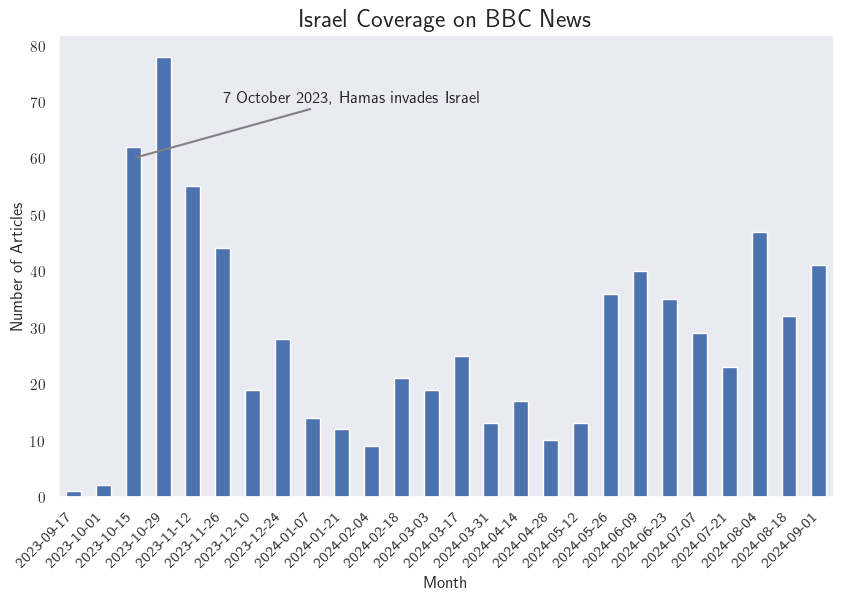

In [10]:
def BBC_coverage(bbc_df: pd.DataFrame) -> None:
    """
    Takes the preprocessed bbc_df DataFrame and shows the distribution over time.
    Compare the coverage over time to the EventRegistry data (last month) and Jackson's work (October 2023) 
   
    :params df: The clean, joined DataFrame.
    :returns: None
    """
    # Create a local copy, set datetime index, and sort
    bbc_df = bbc_df.copy()\
        .assign(dateTimePub=pd.DatetimeIndex(bbc_df.dateTimePub))\
            .dropna(subset='dateTimePub').set_index('dateTimePub').sort_index()

    # Create axis
    # First, limit timespan to september 2023 to september 2024
    ax = bbc_df['2023-09-01':'2024-09-01'].title.resample('2W').count().plot.bar()
    ax.set_xticklabels([date.get_text().split()[0] 
                        for date in ax.get_xticklabels()], rotation=45, ha='right')

    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Articles')
    ax.set_title('Israel Coverage on BBC News', fontsize=18)

    # Annotate the axis for readability
    ax.annotate('7 October 2023, Hamas invades Israel',
                xy=(2, 60), 
                xytext=(5 , 70),  # Move the text away from the point
                textcoords='data',
                arrowprops=dict(
                    arrowstyle="-", 
                    color='gray',
                    lw=1.5 ))

    plt.show()

BBC_coverage(bbc_articles)

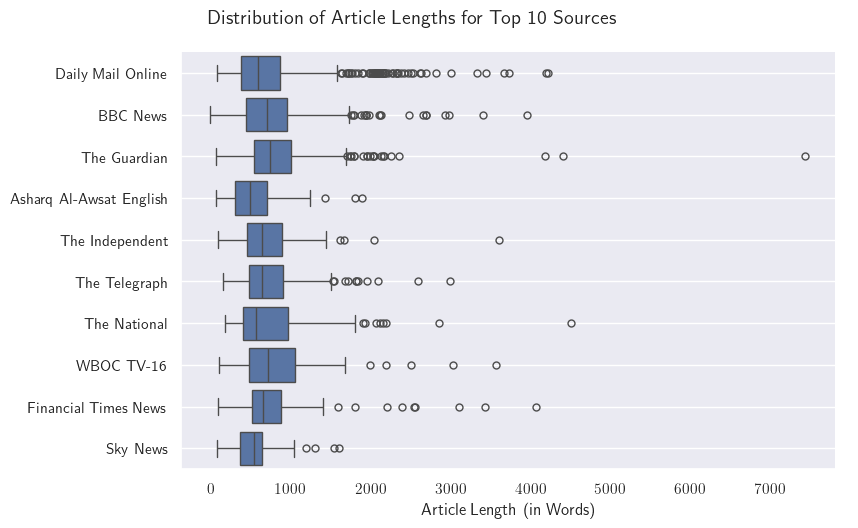

In [139]:
def show_distribution_of_lengths(df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes the ``joined`` DataFrame and shows the variation in article lengths.

    :params df: The clean, joined DataFrame.
    :returns: None
    """
    # Create a local copy, add a length column and sort
    df = df.copy()\
        .assign(len = df.body.str.split().apply(len))\
            .sort_values(by="len", ascending=False)

    top_sources = df.source.value_counts().index[:10]

    filtered_joined = df[df['source'].isin(top_sources)]

    fg = sns.catplot(filtered_joined, x='len', y='source', kind='box', order=top_sources, height=5, aspect=1.75)

    fg.ax.set_xlabel('Article Length (in Words)')
    fg.ax.set_ylabel('')
    fg.ax.grid(axis ='y')
    fg.figure.suptitle('Distribution of Article Lengths for Top 10 Sources', y=1.05)
    
    plt.show()
    
show_distribution_of_lengths(articles_df)

In [142]:
# Reindexing by top newspapers in UK*
publications_circulation = {
    'Metro': 953475,
    'The Sun': 900000,
    'Daily Mail Online': 735857,
    'The Guardian': 500000,
    'The Economist': 490944,   
    'The Telegraph': 300000,
    'Mirror': 240799,  
    'EXPRESS': 152699,
    'The Independent':	126308,
    'Financial Times News': 115118    
    }

index_by_circulation = pd.Series(publications_circulation).index

top_10_circulation = articles_df.source.value_counts().to_frame('').loc[index_by_circulation]
top_10_circulation.index.name = 'Mentions by Circulation'

top_10_circulation

,
Mentions by Circulation,
Metro,14
The Sun,31
Daily Mail Online,998
The Guardian,284
The Economist,20
The Telegraph,119
Mirror,34
EXPRESS,12
The Independent,188


*Sources:
- https://www.mediahq.com/blog/top-ten-uk-newspaper-publications
- https://www.hurstmediacompany.co.uk/
- https://en.wikipedia.org

Note that Newsapi does not return articles from some widely-read sources such as *Evening Standard* and *The Times*. We also made some best guesses, as circulation volumes do not accurately reflect online readership. 

## 3. Analysis

With the preprocessed data in place, we begin our linguistic analysis, focusing on how different media outlets report Palestinian and Israeli deaths. Specifically, we aim to compare mentions of casualties, the verbs used (e.g., "kill," "murder"), and the sentiment associated with these events.

The `process_doc()` function processes each article sentence by sentence. It identifies verbs and their corresponding subjects and objects, determining whether the sentence is in active or passive voice. NLTK's *Sentiment Intensity Analyzer* is then applied to assess the sentiment of each sentence.

The function extracts key elements from each sentence in the article. It identifies:

- **Active vs. Passive Voice**: Dependency parsing is used to determine whether the sentence is active or passive by identifying the subject and object.
- **Actor and Victim**: It identifies the actor (the one performing the action) and the victim (the one affected), focusing on mentions of Israeli and Palestinian entities.
- **Sentiment Analysis**: A numerical sentiment score is generated for each sentence, ranging from negative to positive.

One of the main challenges in the analysis is distinguishing whether deaths are described in the active or passive voice. In the active voice, the *subject* of the sentence is the *actor*, while in the passive voice, the *subject* is the *recipient* of the action, and the action is performed by an *agent*.

**Example**:
- Active: "Israeli forces killed five Palestinians."
- Passive: "Five Palestinians were killed by Israeli forces."

### 3.1 Implementation: Processing the Articles

We utilise SpaCy’s dependency parsing to determine whether a sentence is active or passive. SpaCy’s `nlp` object tokenises the text, creating a `doc` object with a `.sents` property for iterating over sentences. Each sentence (`sent`) contains tokenised words, which provide attributes like `.lemma_`, `.pos_`, `.text`, and `.dep_`. We focus on these dependency labels to identify the syntactic roles of subjects and objects.

Each document also contains named entities (`.ents`), which are iterated over to capture their `.text` and `.label_` attributes, helping us identify key entities in the text.

First, we define several key elements:

1. **Entity Identification**:  
   We use regular expressions (`PALESTINE_IDENTIFIERS`, `ISRAEL_IDENTIFIERS`) to identify mentions of Palestinians and Israelis.

2. **Verbs of Interest**:  
   A list of *aggressive* verbs helps flag sentences that describe violent events, central to our analysis of how media outlets frame violence.

Next, the `process_doc()` function is applied across the dataset, using `progress_apply()` (with `tqdm`) to track progress. This generates a list of processed mentions for each article, capturing details such as the actor, victim, verb, sentiment, and article title.

The processed data is then exploded into a DataFrame, where each mention is represented as a separate row. This format allows for easier manipulation and analysis, with columns detailing the actor, victim, verb (e.g., "killed"), sentiment score, and the entities (Israeli or Palestinian) involved.

In [54]:
nlp = spacy.load("en_core_web_sm")
sia = SentimentIntensityAnalyzer()

PALESTINE_IDENTIFIERS = re.compile(r"palestin|militant|hamas|gaza|west bank", flags=re.IGNORECASE)
ISRAEL_IDENTIFIERS = re.compile(r"israel|military|hostage|settle", flags=re.IGNORECASE)

# Verbs related to deaths
AGGRESSIVE_VERBS = ["kill", "murder", "shoot", "assassinate", "attack", "bomb", "hit"]

logs = {'sentiment': {"palestinian": 0, "israeli": 0}, 
        'mentions': {"palestinian": 0, "israeli": 0}}

def process_doc(row):

    # Process the text
    doc = nlp(row['body'])
    
    mentions_list = []

    for sent in doc.sents:

        verb = obj = agent = None
        subject = passive_subject = None
        actor = victim = None

        mention = {}

        # Skip quotes, as that makes the indirectness tricky
        if '"' in sent.text or '”' in sent.text:
            continue

        # First, find the fatal verb in the sentence
        for token in sent:
            if token.lemma_ in AGGRESSIVE_VERBS and token.pos_ == "VERB":
                verb = token
                break

        if verb:
            # Iterate over each token in the sentence
            for token in sent:
                
                # Active voice: subject (nsubj) and object (dobj)

                # Find subject (nsubj)
                if token.dep_ == "nsubj" and token.head == verb: 
                    subject = token.text

                    # Check for modifiers
                    idx = [child.i for child in token.children if child.dep_ in ["poss", "amod", "compound"]]
                    if idx:
                        modifiers = doc[idx[0]].text

                        if doc[idx[0]-2].dep_ == "npadvmod":
                            modifiers = doc[idx[0]-2].text + " " + modifiers
                        
                        if modifiers:
                            subject = modifiers + " " + token.text
                    
                    # Replace that or which with its head (~subject)
                    if token.text in ['that', 'which']:
                        subject = token.head.head.text

                # Find object (dobj)        
                if token.dep_ == "dobj" and token.head == verb:
                    obj = token.text
                    
                    # Check if there's a number preceding the victims
                    if token.i > 0:
                        if (nummod := token.nbor(-1)).dep_ == 'nummod':
                            obj = nummod.text + ' ' + token.text

                # Passive voice: subject (nsubjpass) and agent's child (agent is 'by')

                # Find passive subject (nsubjpass)
                if token.dep_ == "nsubjpass" and token.head == verb:
                    passive_subject = token

                    # Check if there's a number preceding the victim
                    if token.i > 0:
                        if (nummod := token.nbor(-1)).dep_ == 'nummod':
                            passive_subject = nummod.text + ' ' + token.text

                # Find agent's neighbour (agent + nbor)
                if token.dep_ == "agent" and token.head == verb:                   
                    agent_nbor = token.nbor() # note: agent is "by", so we need its neigbour

            # Calculate sentiment
            sentiment = sia.polarity_scores(sent.text)

            # Assign actor and victim role
            if agent and passive_subject:
                actor = agent_nbor.text.lower()
                victim = passive_subject.text.lower()

            elif subject and obj: 
                actor = subject.lower()
                victim = obj.lower()
            
            else:
                continue # when syntax is malformed
            
            # Check if actor or victim is Palestinian or Israeli respectively
            if (victim and re.search(PALESTINE_IDENTIFIERS, victim)) or \
                (actor and re.search(ISRAEL_IDENTIFIERS, actor)):
                logs['sentiment']['palestinian'] += float(sentiment['compound'])
                logs['mentions']['palestinian'] += 1

                mention['mention'] = 'palestinian'
                mention['sentiment'] = float(sentiment['compound'])
                
            elif victim and re.search(ISRAEL_IDENTIFIERS, victim) or\
                (actor and re.search(PALESTINE_IDENTIFIERS, actor)):       
                logs['sentiment']['israeli'] += float(sentiment['compound'])
                logs['mentions']['israeli'] += 1

                mention['mention'] = 'israeli'
                mention['sentiment'] = float(sentiment['compound'])

            else: 
                # print(f"Failed to classify victim: '{victim}', with actor: '{actor}'")
                mention['sentiment'] = float(sentiment['compound'])
                mention['mention'] = np.nan

            # Log further details
            mention['article_title'] = row['title']
            mention['sentence'] = sent.text
            mention['actor'] = actor
            mention['victim'] = victim
            mention['verb'] = verb.text
            
            mentions_list.append(mention)
    
    if mentions_list:
        return mentions_list

In [55]:
# Apply the above function to create a Series
# Takes ~9 minutes
analysed = articles_df.progress_apply(process_doc, axis=1)

100%|██████████| 4337/4337 [08:50<00:00,  8.17it/s]


In [56]:
# Construct a new DataFrame

# Define columns explicitly to order them
cols = ['actor','verb', 'victim', 'article_title', 'sentence', 'mention', 'sentiment']

# Explode the lists of dicts
analysed_expl = analysed.dropna().explode()

nlp_df = pd.DataFrame(analysed_expl.to_list(), 
                    index=analysed_expl.index, 
                    columns=cols)

In [69]:
f"We have {(nlp_df.mention == 'israeli').sum()} mentions of israeli victims and {(nlp_df.mention == 'palestinian').sum()} mentions of palestinian victims and {(nlp_df.mention.isna()).sum()} NaNs (indicating syntax parsing errors)."

'We have 496 mentions of israeli victims and 1059 mentions of palestinian victims and 1454 NaNs (indicating syntax parsing errors).'

### 3.2 Mapping Mentions to Sources

To accurately track and attribute the mentions of Palestinian and Israeli casualties to their respective news sources, we follow a two-step process:

1. **Joining Mentions with Articles**:
   We start by joining the DataFrame containing the analysed mentions (i.e., the output from our NLP analysis) with the original articles DataFrame. This step adds essential metadata such as the article’s source, publication date, and other relevant fields to each mention. By doing this, we can directly link each analysed sentence (mention of a casualty) to its originating news source, making it possible to track the distribution of mentions across outlets.

2. **Expanding to Include Duplicate Sources**:
   Since some articles appear in multiple outlets (especially local newspapers), we account for duplicates by mapping each body of text to a set of sources. We do this by using a precomputed mapping of duplicates, stored in a JSON file. This mapping allows us to attribute the same mention to multiple outlets if applicable. 

This two-step process allows us to systematically map mentions of casualties to their original sources while accounting for duplicated content across multiple outlets. In the following step, we will then analyse how different media outlets report on the conflict and compare their respective biases or indifferences towards Palestinian and Israeli deaths.

In [385]:
# Use the preprocessed sample from 2.2.1
# Drop all ``NaN`` mentions.
# Use the index to join the ``analysis`` onto the ``articles``
analysed_articles = nlp_df.dropna(subset='mention')\
    .join(articles_df, how='left', lsuffix='_sia')

In [386]:
# Join onto the ``duplicates_mapping``
with open('data/duplicates_mapping.json', 'r') as f:
    duplicates_dict = json.loads(f.read())

mapped_series = analysed_articles['body'].map(lambda body: duplicates_dict.get(body, None))

In [387]:
# Explode the mapping into a DataFrame with the column ``source`` 
# Note that the index matches ``left_join`` 
mapped_df = mapped_series[mapped_series.notna()].explode().to_frame('source')

# Another left join to retain only the subset of left_join that exists in mapped_df
mapped_df_joined = mapped_df.join(analysed_articles.drop('source', axis=1))

# Concat onto original to complete the mapping of mentions to sources
analysed_mapped = pd.concat([analysed_articles, mapped_df_joined])

# Housekeeping
analysed_mapped.mention = analysed_mapped.mention.astype('category')

### 3.3 Summary of results 

#### 3.3.1 Mentions by BBC News

In this section, we provide an overview of the key findings of our analysis. We begin with BBC News. We start by counting the mentions of each entity (Palestinian or Israeli) across the dataset, showing how often each group is referenced. 

Next, we show the mentions over time. By doing this, we show the trend over time in BBC News reports on Palestinian and Israeli deaths, highlighting patterns in their reporting.

We also show the sentence-level sentiment for BBC News articles over time, aggregating the scores we computed in the above analysis. Note that this is an imperfect measure and should not be taken literally. However, it gives an indication and a wider trend is noticeable. 

Finally, we will contrast the media mentions with the actual casualty data from Gaza, comparing the reports from BBC News and various UK media outlets with on-the-ground data provided by the Gaza Ministry of Health. 

In [3]:
# Load dataset with all the above processing:

analysed_mapped = pd.read_parquet('data/analysed_mapped')
analysed_articles = pd.read_parquet('data/analysed_articles')

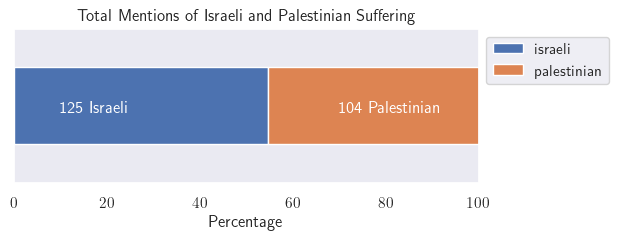

In [187]:
mentions_by_bbc = analysed_mapped.query('"BBC News" in source')

BBC_value_counts = mentions_by_bbc.mention.value_counts()
BBC_pct = BBC_value_counts.div(BBC_value_counts.sum()) * 100

ax = BBC_pct.to_frame().T.plot.barh(stacked=True, figsize=(6,2)) 

ax.set_title('Total Mentions of Israeli and Palestinian Suffering')
ax.set_xlim(0,100)
ax.set_yticklabels('')
ax.set_xlabel('Percentage')
ax.text(10, -0.04, f'{BBC_value_counts.iloc[0]} Israeli', c='w')
ax.text(70, -0.04, f'{BBC_value_counts.iloc[1]} Palestinian', c='w')
ax.legend(bbox_to_anchor=[1,1])
plt.show()

***Table 1.*** *The count and proportion of mentions of Palestinian or Israeli suffering, showing how often each group is referenced. This gives us with an understanding of the overall distribution of mentions in the media coverage.*

In [68]:
# Get an index by month
mentions_by_bbc_ = mentions_by_bbc.copy()\
    .assign(year_month=mentions_by_bbc.dateTimePub.map(lambda idx: idx.strftime('%Y-%m')))\
    .set_index('year_month')

# Group by mention
overview_bbc = mentions_by_bbc_[['mention', 'article_title']]\
    .groupby(['year_month', 'mention'], observed=False).count()\
        .unstack()

# Drop top level of the MultiIndex
overview_bbc.columns = overview_bbc.columns.map(lambda col: col[1])

# Add a percentage of total df
def add_percentage(overview_bbc):
    overview_bbc = overview_bbc.copy()
    proportions = overview_bbc.div(overview_bbc.sum(axis=1), axis=0) * 100
    return overview_bbc.join(proportions.astype(int), lsuffix='_abs', rsuffix='_pct')

overview_bbc = add_percentage(overview_bbc)

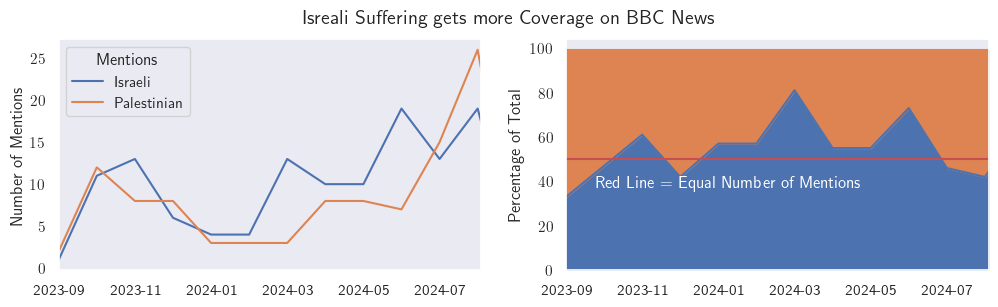

,israeli_pct,palestinian_pct
year_month,,
2023-10,47,52
2023-11,61,38
2023-12,42,57
2024-01,57,42
2024-02,57,42
2024-03,81,18
2024-04,55,44
2024-05,55,44
2024-06,73,26


In [597]:
fig, axs = plt.subplots(1,2, figsize=(12,3))

overview_bbc[['israeli_abs', 'palestinian_abs']].plot.line(ax=axs[0])
axs[0].set_xlim(0,11.1)
axs[0].set_ylabel('Number of Mentions')
axs[0].set_xlabel('')
axs[0].legend(labels=['Israeli', 'Palestinian'], handles=axs[0].get_legend_handles_labels()[0], title='Mentions', loc='upper left')

# Show the percentage of total as a second plot
overview_bbc[['israeli_pct', 'palestinian_pct']].plot.area(ax=axs[1])
axs[1].hlines(50, axs[0].get_xlim()[0], axs[1].get_xlim()[1], color='r')
axs[1].text(0.8,37,'Red Line = Equal Number of Mentions', fontsize=12, c='w')

axs[1].set_xlim(0,11.1)
axs[1].set_xlabel('')
axs[1].set_ylabel(r'Percentage of Total')

axs[1].legend().set_visible(False)

plt.suptitle('Isreali Suffering gets more Coverage on BBC News')
plt.show()

# Show table with only solid figures
overview_bbc.iloc[1:-1,-2:]\
    .style.highlight_max()      # Highlight the false balance

***Table 2.*** *The mentions over time show a clear trend. Higher palestinian mentions coincide with a higher number of mentions of the Isreali victims.*

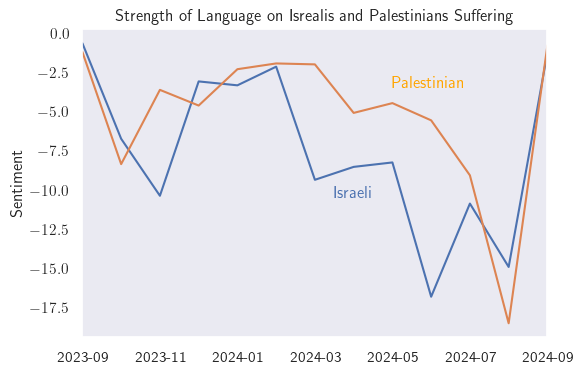

sentiment_sia            
mention          israeli palestinian
year_month                          
2023-09          -0.6705     -1.2279
2023-10          -6.7549     -8.3698
2023-11         -10.3865     -3.6387
2023-12          -3.1005     -4.6384
2024-01          -3.3496     -2.3224
2024-02          -2.1605     -1.9551
2024-03          -9.3688     -2.0150
2024-04          -8.5460     -5.1067
2024-05          -8.2630     -4.4833
2024-06         -16.8183     -5.5810
2024-07         -10.8831     -9.0841
2024-08         -14.9218    -18.5104
2024-09          -1.2714     -0.8126

In [620]:
# Show the sentence-level sentiment for BBC News
sentiment_bbc = mentions_by_bbc_[['sentiment_sia', 'mention']]\
    .groupby(['year_month', 'mention'], observed=False).sum().unstack()

ax = sentiment_bbc.plot.line(figsize=(6,4))
ax.set_xlim(0,12)
ax.set_xlabel('')
ax.set_ylabel(r'Sentiment')
ax.legend().set_visible(False)
axs[0].legend(labels=['Israeli', 'Palestinian'], handles=axs[0].get_legend_handles_labels()[0], title='Mentions', loc='upper left')

plt.title('Strength of Language on Isrealis and Palestinians Suffering ')
ax.text(8,-3.5,'Palestinian', fontsize=12, c='orange')
ax.text(6.5,-10.5,'Israeli', fontsize=12, c='b')
plt.show()

sentiment_bbc

***Table 3.*** *The sentence-level sentiment for BBC News articles over time. Despite the necessary caveats around methodology, we notice a wider trend of increasing negative sentiment.*

In [373]:
casualties_daily = pd.read_csv(r'data/casualties_daily.csv')

casualties_daily = casualties_daily.set_index(pd.DatetimeIndex(casualties_daily.report_date))

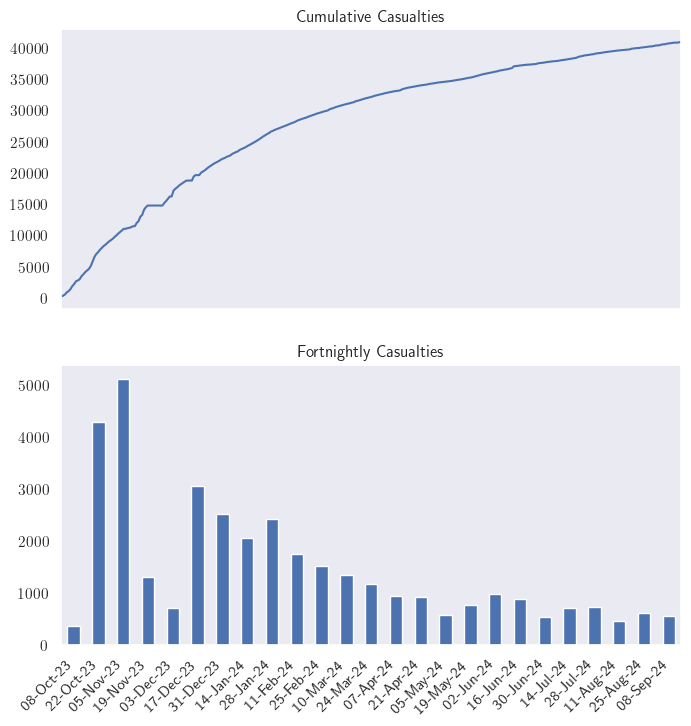

In [374]:
fig, axs = plt.subplots(2,1, figsize=(8,8))

casualties_daily.ffill().plot(y='killed_cum', ax=axs[0])
axs[0].set_title('Cumulative Casualties')
axs[0].set_xlabel('')
axs[0].set_xticklabels([])
axs[0].legend().set_visible(False)

two_weekly = casualties_daily.resample('2W').sum()
two_weekly.index = two_weekly.index.map(lambda x: x.strftime('%d-%b-%y'))

two_weekly.plot.bar(y='killed', ax=axs[1])
axs[1].set_title('Fortnightly Casualties')
axs[1].set_xlabel('')
axs[1].set_xticklabels([date.get_text().split()[0] for i, date in enumerate(axs[1].get_xticklabels())], rotation=45, ha='right')
axs[1].legend().set_visible(False)

plt.show()

**Contrasted with Gaza Casualties:**
Using a data from the Gaza Ministry of Health, we contrast the mentions of suffering with the situation on the ground. A dataset compiled by [TechForPalestine](https://data.techforpalestine.org/) provides daily values for those killed and injured in the Gaza Strip since October 7th, 2023.

#### 3.3.2 Mentions by All Sources (Last Month Only)

In this section, we shift our focus to the most recent month of data, examining how different media outlets reported on the Palestinian-Israeli conflict during this period. We will start by showing the number of mentions for both Israeli and Palestinian casualties across the top sources, excluding duplicates. This will help us identify which outlets have the most balanced or biased reporting patterns.

We will then expand the analysis to include syndicated articles, providing insight into how mentions are distributed across both original and republished content. This step will allow us to observe high rates of mentions in primarily local newspapers. Additionally, we will perform the same analysis for the top 10 newspapers by circulation, offering a more accurate reflection of the UK media landscape. This overview emphasises the low rates of mentions in certain tabloid-style newspapers, consistent with the low number of articles on the topic discussed in the summary analysis in Section 2.3.2.

Next, we will explore *sentiment* by source for the last month, focusing on the tone of the mentions (positive, neutral, or negative) for both Israeli and Palestinian references. By calculating the overall sentiment for each source, we aim to uncover whether different outlets express stronger emotional responses toward one group compared to the other.

Throughout the analysis, we will make use of visual tools to present the data in a clear and intuitive manner, including highlighting key percentages and comparisons. This will allow us to draw meaningful conclusions about the media's reporting and potential biases during the most recent phase of the conflict.

In [192]:
# Take the last month
last_month = analysed_articles.copy().set_index('dateTimePub').sort_index()['2024-08-08':]

# Sort by total ``mentions``
top_10_sources = last_month.source.value_counts().index[:10]

# Use groupby to order by count of ``source`` and ``mention``
overview_df = last_month[['source', 'mention', 'article_title']]\
    .groupby(['source', 'mention'],observed=False).count()\
    .loc[top_10_sources].unstack()

# Drop one level of MultiIndex for readability 
overview_df.columns = overview_df.columns.map(lambda col: col[1])

# Add a percentage of total df
overview_df = add_percentage(overview_df)

# Showing the mentions by source (duplicates excluded)
overview_df\
    .drop(['israeli_abs', 'palestinian_abs'], axis=1)\
    .style.highlight_between(
        subset=['israeli_pct', 'palestinian_pct'], 
        left=45, right=55)  # Highlighting the nearly even split for BBC

,israeli_pct,palestinian_pct
source,,
Daily Mail Online,28,71
Asharq Al-Awsat English,22,77
The Independent,21,78
WBOC TV-16,25,74
WGAL 8 Lancaster/Harrisburg,23,76
The Guardian,21,78
BBC News,51,48
Belfast Telegraph,43,56
The Irish News,40,60


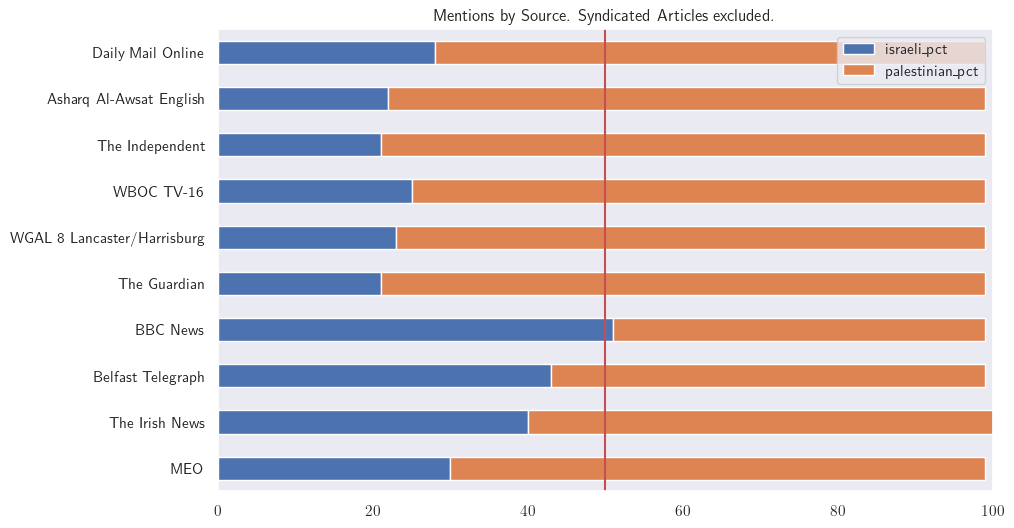

,israeli_abs,palestinian_abs,israeli_pct,palestinian_pct
source,,,,
Daily Mail Online,150,370,28,71
Asharq Al-Awsat English,24,84,22,77
The Independent,17,62,21,78
WBOC TV-16,19,55,25,74
WGAL 8 Lancaster/Harrisburg,14,45,23,76
The Guardian,10,37,21,78
BBC News,18,17,51,48
Belfast Telegraph,14,18,43,56
The Irish News,12,18,40,60


In [166]:
# Take the last month
last_month = analysed_articles.copy().set_index('dateTimePub').sort_index()['2024-08-08':]

# Sort by total ``mentions``
top_10_sources = last_month.source.value_counts().index[:10]

# Use groupby to order by count of ``source`` and ``mention``
overview_df = last_month[['source', 'mention', 'article_title']]\
    .groupby(['source', 'mention'],observed=False).count()\
    .loc[top_10_sources].unstack()

# Drop one level of MultiIndex for readability 
overview_df.columns = overview_df.columns.map(lambda col: col[1])

# Add a percentage of total df
overview_df = add_percentage(overview_df)

# Plot
ax = overview_df.drop(['israeli_abs', 'palestinian_abs'], axis=1).iloc[::-1].plot.barh(stacked=True)
ax.set_ylabel('')
ax.set_xlim(0,100)

# Draw reference line
plt.vlines(50, ax.get_xlim()[0]-0.5, ax.get_xlim()[1], colors='r')

plt.title('Mentions by Source. Syndicated Articles excluded.')
plt.show()

overview_df.style.highlight_between(
        subset=['israeli_pct', 'palestinian_pct'], 
        left=45, right=55)  # Highlighting the nearly even split for BBC

***Table 4.*** *The number of mentions for both Israeli and Palestinian casualties across the top sources, excluding duplicates. Here we notice BBC News is the outlier.*

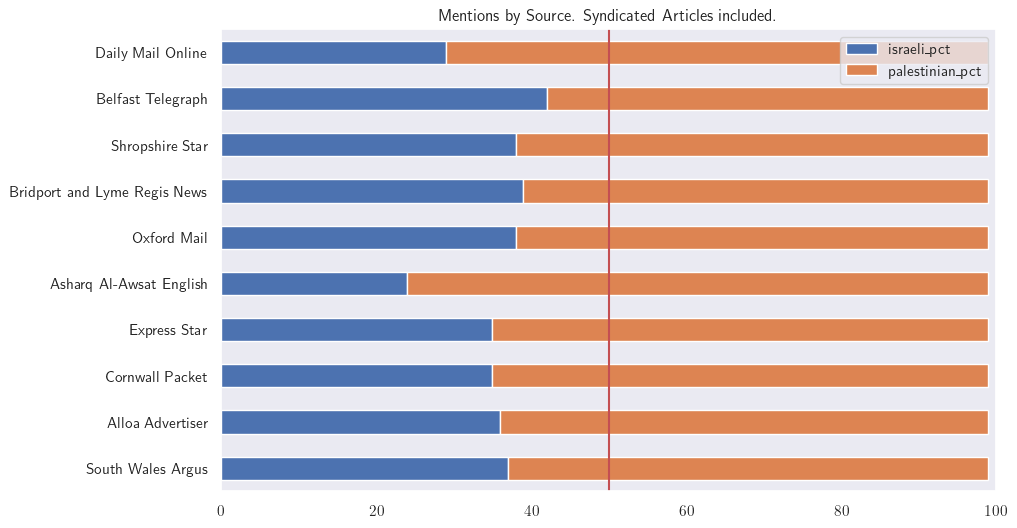

In [242]:
# Including the 3,035 syndicated articles shows local newspapers top the total number of mentions

# Take the last month
last_month = analysed_mapped.copy().set_index('dateTimePub').sort_index()['2024-08-08':]

# Sort by total ``mentions``
top_10_sources = last_month.source.value_counts().index[:10]

# Use groupby to order by count of ``source`` and ``mention``
overview_df = last_month[['source', 'mention', 'article_title']]\
    .groupby(['source', 'mention'],observed=False).count()\
    .loc[top_10_sources].unstack()

# Drop one level of MultiIndex for readability 
overview_df.columns = overview_df.columns.map(lambda col: col[1])

# Add a percentage of total df
overview_df = add_percentage(overview_df)

overview_df = overview_df.rename(index={'Express & Star': 'Express Star'})

ax = overview_df.drop(['israeli_abs', 'palestinian_abs'], axis=1).iloc[::-1].plot.barh(stacked=True)
ax.set_ylabel('')
ax.set_xlim(0,100)

plt.vlines(50, ax.get_xlim()[0]-0.5, ax.get_xlim()[1], colors='r')

plt.title('Mentions by Source. Syndicated Articles included.')
plt.show()

***Table 5.*** *Including both original and republished content, we notice high rates of mentions in mostly local newspapers.*

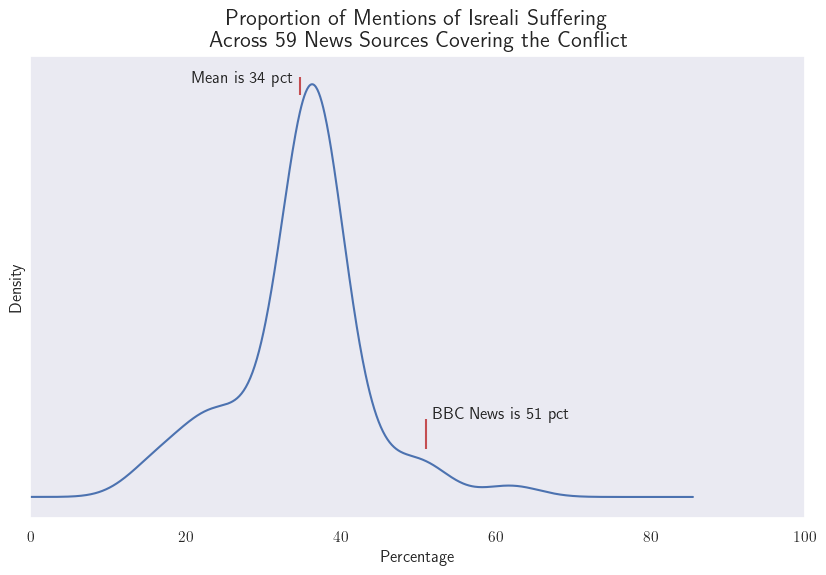

In [255]:
# Show a global overview of Israeli mentions (as a proportion of total mentions) across all sources that cover the conflict

# Take the last month
last_month = analysed_mapped.copy().set_index('dateTimePub').sort_index()['2024-08-08':]

# As before
overview_df = last_month[['source', 'mention', 'article_title']]\
    .groupby(['source', 'mention'],observed=False).count().unstack()
overview_df.columns = overview_df.columns.map(lambda col: col[1])

# Select Sources with at Least Two Mentions 
at_least_two_mentions = overview_df[(overview_df.israeli > 1) & (overview_df.palestinian > 1)] 

at_least_two_mentions = add_percentage(at_least_two_mentions)

# Plot
ax = at_least_two_mentions['israeli_pct'].plot.density()

# Add text
ax.text(52, 0.013, 'BBC News is 51 pct')
plt.vlines(51,0.008,0.013, colors='r')

plt.text(at_least_two_mentions['israeli_pct'].mean()-14, 0.069, f"Mean is {at_least_two_mentions['israeli_pct'].mean().astype(int)} pct")
plt.vlines(at_least_two_mentions['israeli_pct'].mean(),0.067, 0.07, colors='r')

# Reduce clutter
ax.set_xlim(0,100)
ax.set_yticks([])
ax.set_xlabel('Percentage')
ax.set_title(f'Proportion of Mentions of Isreali Suffering \nAcross {at_least_two_mentions.shape[0]} News Sources Covering the Conflict', fontsize=16)
plt.show()

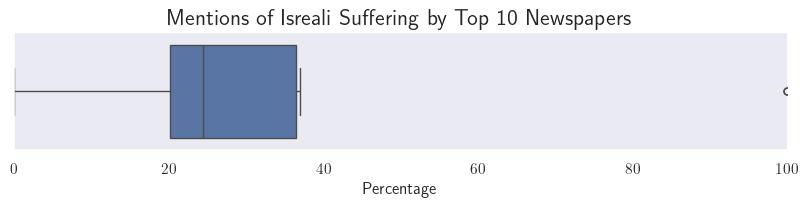

,israeli_abs,palestinian_abs,israeli_pct,palestinian_pct
Metro,0,4,0,100
The Sun,1,0,100,0
Daily Mail Online,150,370,28,71
The Guardian,10,37,21,78
The Economist,1,4,20,80
The Telegraph,5,9,35,64
Mirror,3,5,37,62
EXPRESS,1,0,100,0
The Independent,17,62,21,78
Financial Times News,2,9,18,81


In [254]:
# Show the mentions by source (top 10 in terms of circulation)

# Take the last month
last_month = analysed_articles.copy().set_index('dateTimePub').sort_index()['2024-08-08':]

overview_df = last_month[['source', 'mention', 'article_title']]\
    .groupby(['source', 'mention'],observed=False).count().unstack()\
        .loc[index_by_circulation].fillna(0).astype(int)

# Drop one level of MultiIndex for readability 
overview_df.columns = overview_df.columns.map(lambda col: col[1])

# Add a percentage of total df
overview_df = add_percentage(overview_df)

# plot
fg = sns.catplot(overview_df, x='israeli_pct', kind='box', height=2, aspect=4)
fg.ax.set_xlim(0,100)
fg.ax.set_xlabel('Percentage')
plt.title('Mentions of Isreali Suffering by Top 10 Newspapers', fontsize=16)
plt.show()

# Add a rank and return
overview_df.style.highlight_min(subset=['palestinian_abs'])     # Highlighting the empty values for tabloids

***Table 6.*** *This overview ranked by the top 10 newspapers by circulation reflects the UK media landscape more accurately. Here we highlight the low rates of mentions in some (tabloid-style) newspapers. This reflects the low number of articles on the topic which we discussed in the summary analysis in 2.3.2.*

In [189]:
# Show the sentence-level sentiment across media
# As discussed in the introduction this technique prone to bias, and should be treated with care.

# Take the last month
sentiment = analysed_articles.copy().set_index('dateTimePub').sort_index()['2024-08-08':]

# Sort by total ``mentions``
top_10_sources = sentiment.source.value_counts().index[:10]

sentiment = sentiment[['source', 'mention', 'sentiment_sia']]\
        .groupby(['source', 'mention', 'sentiment_sia'],observed=False).sum()\
                .reset_index().pivot_table(index='source', columns='mention', values='sentiment_sia', aggfunc='sum').loc[top_10_sources].astype(int)

# Add percentage and drop absolute values
sentiment = add_percentage(sentiment).drop(['israeli_abs', 'palestinian_abs'], axis=1)
sentiment.columns = sentiment.columns.rename('Sentiment')

sentiment.style.highlight_max(
    subset=['israeli_pct', 'palestinian_pct']
    )        # Highlighting the high percentages for The Guardian and the Belfast Telegraph

Sentiment,israeli_pct,palestinian_pct
source,,
Daily Mail Online,39,60
Asharq Al-Awsat English,26,73
The Independent,34,65
WBOC TV-16,35,64
WGAL 8 Lancaster/Harrisburg,27,72
The Guardian,21,78
BBC News,43,56
Belfast Telegraph,58,41
The Irish News,46,53


***Table 6.*** *The sentiment by source for the last month aggregates the tone of the mentions for both Israeli and Palestinian references. By presenting the overall sentiment for each source as a percentage, we highlight how different outlets express stronger emotional responses toward one group compared to the other. (Note that this methodology has limitations. Cf. Chen et al.,2010, Exploring Political Standpoints Using an Opinion Scoring Model.)*

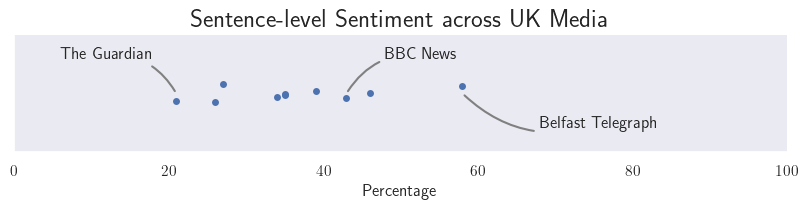

In [278]:
# Plot sentiment
fg = sns.catplot(sentiment, x='israeli_pct', height=2, aspect=4)

# Manual annotations
x = sentiment.loc['The Guardian', 'israeli_pct']
fg.ax.annotate('The Guardian', xy=(x, 0), xytext=(x - 15, -0.3), textcoords='data',
            arrowprops=dict(arrowstyle="-", connectionstyle="arc3,rad=-.3", color='gray', lw=1.5 ))

x = sentiment.loc['BBC News', 'israeli_pct']
fg.ax.annotate('BBC News', xy=(x, 0), xytext=(x + 5, -0.3), textcoords='data',
            arrowprops=dict(arrowstyle="-", connectionstyle="arc3,rad=.3",color='gray',lw=1.5 ))

x = sentiment.loc['Belfast Telegraph', 'israeli_pct']
fg.ax.annotate('Belfast Telegraph', xy=(x, 0), xytext=(x + 10, 0.3), textcoords='data',
            arrowprops=dict(arrowstyle="-", connectionstyle="arc3,rad=-.3",color='gray',lw=1.5 ))

fg.ax.set_xlim(0,100)
fg.ax.set_xlabel('Percentage')
plt.title('Sentence-level Sentiment across UK Media', fontsize=18)
plt.show()

## 4. Conclusion

By examining active versus passive voice constructions, identifying the actors involved, and applying sentiment analysis, we have uncovered patterns that suggest varying degrees of bias and indifference. We analysed a total of 4,337 articles, including 3,683 from the API (narrowed down from 6,218) and 744 scraped from BBC News. To avoid inflating our analysis with repeated content, we used a mapping system to account for 3,035 republished articles, largely from local newspapers. In total, we identified over 5,401 mentions related to the conflict, 1,555 of which were unique.

Our findings reveal that **BBC News** made 229 mentions of suffering from both sides. In comparison, during the single month for which we gathered data, the **Daily Mail** made 520 mentions, 71% of which focused on Palestinian casualties. Interestingly, BBC News appears to balance its reporting, with near equal mentions of suffering from both sides (51% related to Israeli suffering), making it the only outlet that reported more on Israeli casualties over the last month. This is in line with a long-term trend.

When aggregating the sentiment scores calculated at the sentence level, **The Guardian** emerged as using the strongest language in condemning violence against Palestinians. However, it is crucial to acknowledge that sentiment analysis techniques, while valuable, are not perfectly suited for such complex and nuanced contexts, and our methodology included several necessary simplifications.

For future research, an *aspect-level* opinion mining approach, as discussed in Liu et al. (2012), offers promising potential for more granular analysis of opinions and sentiments. Additionally, transformer-based architectures present exciting avenues for further development in sentiment analysis and media bias detection. One of my personal goals is to explore the limits of fine-tuning such models for opinion mining and classification, aiming to enhance the accuracy and depth of analysis in complex media narratives.

Our broader analysis highlights noticeable differences in how UK media outlets cover the Palestinian-Israeli conflict, most notably the national broadcaster, the BBC. We find clear evidence of a false equivalence obscuring the disproportionate suffering of one group. Given the BBC's role in shaping public perception of the conflict, the false balance between two opposing narratives and the lack of normative judgment and empathy, is problematic. These findings provide a basis for further research into UK news and broadcasting standards and the BBC's much vaunted impartiality. 

## 5. References


1. Wagner, W., 2010. Steven Bird, Ewan Klein and Edward Loper: Natural Language Processing with Python, Analyzing Text with the Natural Language Toolkit - O'Reilly Media, Beijing, 2009, ISBN 978-0-596-51649-9. *Language Resources and Evaluation*, 44(4), pp.421-424. doi: 10.1007/S10579-010-9124-X.

2. Liu, B., 2012. Sentiment Analysis and Opinion Mining. In: *Encyclopedia of Machine Learning and Data Mining*. Springer US, pp.1-10. doi: 10.1007/978-1-4899-7502-7_907-1.

3. TechForPalestine, 2023. Gaza casualties dataset. [online] Available at: <https://data.techforpalestine.org/docs/casualties-daily/> [Accessed 9 Sep. 2024].

4. McKinney, W., 2014. *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*. 1st ed. Beijing: O'Reilly, pp.1-447. ISBN: 1449319793.

5. Chen, B., Zhu, L., Kifer, D. and Lee, D., 2010. What Is an Opinion About? Exploring Political Standpoints Using Opinion Scoring Model. *Proceedings of the AAAI Conference on Artificial Intelligence*, 24(1), pp.1007-1012. doi: 10.1609/aaai.v24i1.7717.

6. Liu, B., 2009. Entity Discovery and Assignment for Opinion Mining Applications. In: *Proceedings of the 15th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD09)*. New York: ACM. doi: 10.1145/1557019.1557141.

7. NewsAPI, 2024. NewsAPI. [online] Available at: <https://www.newsapi.ai/> [Accessed 9 Sep. 2024]. 

8. Jackson, H., 2023. *Casualty Mentions in the New York Times*. [online] GitHub. Available at: <https://github.com/hollyjackson/casualty_mentions_nyt> [Accessed 9 Sep. 2024].


In [7]:
def extract_index():
    with open(r'./CW2.ipynb') as json_file:
        data = json.load(json_file)

    markdown = []
    for cell in data['cells']:

        if cell['cell_type'] == 'markdown':
            for line in cell['source']:
                if "##" in line:
                    stripped_line = line.replace('#', '').strip()
                    stripped_line_ = stripped_line.lower().replace('. ', '-').replace(' ', '-')
                    markdown.append(f"- [{stripped_line}](#{stripped_line_})\n")
    return ''.join(markdown)
    
print(extract_index())

- [Quantifying Indifference Towards Palestinian Suffering Across UK News Sources](#quantifying-indifference-towards-palestinian-suffering-across-uk-news-sources)
- [1. Introduction](#1-introduction)
- [1.1 Research Questions and Objectives](#1.1-research-questions-and-objectives)
- [1.2 Methodology](#1.2-methodology)
- [1.3 Theoretical Framework](#1.3-theoretical-framework)
- [Notes on Scraping and the Use of APIs](#notes-on-scraping-and-the-use-of-apis)
- [2. Data Extraction and Preprocessing](#2-data-extraction-and-preprocessing)
- [2.1 BBC News Scraper](#2.1-bbc-news-scraper)
- [2.1.1 Preprocessing the Scraped Data](#2.1.1-preprocessing-the-scraped-data)
- [2.2 NewsAPI Extraction](#2.2-newsapi-extraction)
- [2.2.1 Data Overview and Preprocessing](#2.2.1-data-overview-and-preprocessing)
- [2.2.2 Handling Duplicates](#2.2.2-handling-duplicates)
- [2.3 Summary of Exploratory Analysis](#2.3-summary-of-exploratory-analysis)
- [2.3.1 Joining the datasets.](#2.3.1-joining-the-datasets.)
- 